In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=eWjsClehJqM3FpOckpb24HEbp9R4Yy&access_type=offline&code_challenge=_tvt9EawOx6mJ-34lWkL5w-x3JPvn9p1s01R6ltPOsY&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


Updates are available for some Google Clo

In [2]:
!gcloud auth login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=jjFXFNYjKe05IpPoYXOvDDvkCJ0Uiy&access_type=offline&code_challenge=562p18p2bwr4PfncDRPLMj81UVt8ycaCXOpCOmJJtcU&code_challenge_method=S256


You are now logged in as [yt4@sanger.ac.uk].
Your current project is [open-targets-genetics-dev].  You can change this setting by running:
  $ gcloud config set project PROJECT_ID


In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep

Loading BokehJS ...

In [3]:
"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/22 16:05:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/05/22 16:05:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
path_to_release_folder="gs://open-targets-data-releases/25.03/"
si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

# Study index

In [8]:
si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")

In [9]:
si.df.count()

1962369

In [9]:
#si.df.filter(f.col("pubmedId")=="37156999").show()

In [10]:
#si.df.filter(f.col("pubmedId").isin(["37770635","36539618","30510241"])).show()

In [ ]:
#si_6=StudyIndex.from_parquet(session,"gs://ot_orchestration/releases/24.10_freeze6/study_index/")

In [ ]:
#si_6.df.count()

1971049

In [ ]:
#si_6.df.groupBy("studyType").count().show()

+---------+------+
|studyType| count|
+---------+------+
|     gwas| 90903|
|     sqtl|185337|
|     pqtl|  3756|
|    tuqtl|301140|
|     eqtl|959304|
|  sctuqtl| 63143|
|   sceqtl|338050|
|   scsqtl| 29416|
+---------+------+



In [10]:
si.df.groupBy("studyType").count().show()

+---------+-------+
|studyType|  count|
+---------+-------+
|     gwas|  96404|
|     sqtl| 213959|
|     pqtl|   3757|
|    tuqtl| 364283|
|     eqtl|1233883|
|   sceqtl|  50083|
+---------+-------+



In [12]:
si.df.groupBy("qualityControls").count().show(100,truncate=False)

+-----------------------------------------------------------------+-------+
|qualityControls                                                  |count  |
+-----------------------------------------------------------------+-------+
|[]                                                               |1902866|
|[The number of SNPs in the study is below the expected threshold]|1598   |
|[Harmonized summary statistics are not available or empty]       |57905  |
+-----------------------------------------------------------------+-------+



In [13]:
si.df.groupBy("analysisFlags").count().show(100,truncate=False)

+-----------------------+-------+
|analysisFlags          |count  |
+-----------------------+-------+
|[Multivariate analysis]|331    |
|[ExWAS]                |3679   |
|[]                     |1939398|
|[Non-additive model]   |50     |
|[Metabolite]           |18636  |
|[GxG]                  |58     |
|[GxE]                  |142    |
|[Case-case study]      |75     |
+-----------------------+-------+



In [11]:
si.df.groupBy("projectId").count().show(100,truncate=False)

+---------------------+-------+
|projectId            |count  |
+---------------------+-------+
|Bossini-Castillo_2019|12434  |
|FINNGEN_R12          |2303   |
|Jerber_2021          |4870   |
|Fairfax_2014         |16009  |
|CEDAR                |14213  |
|ROSMAP               |35095  |
|Nathan_2022          |10542  |
|Braineac2            |3307   |
|Sun_2018             |802    |
|Walker_2019          |10579  |
|HipSci               |25749  |
|van_de_Bunt_2015     |5284   |
|Nedelec_2016         |22956  |
|BrainSeq             |36110  |
|Aygun_2021           |6562   |
|Kasela_2017          |3194   |
|BLUEPRINT            |59835  |
|GEUVADIS             |26871  |
|OneK1K               |14365  |
|TwinsUK              |68319  |
|UKB_PPP_EUR          |2955   |
|Alasoo_2018          |24554  |
|Kim-Hellmuth_2017    |5254   |
|GTEx                 |1070288|
|FUSION               |64657  |
|Schmiedel_2018       |74879  |
|Young_2019           |1793   |
|Steinberg_2020       |7680   |
|Fairfax

In [15]:
si_inv=StudyIndex.from_parquet(session,path_to_release_folder+"invalid_study_index")

AnalysisException: [PATH_NOT_FOUND] Path does not exist: gs://open-targets-pre-data-releases/2503-testrun-3/invalid_study_index.

In [15]:
si_inv.df.count()

50607

In [16]:
si_inv.df.groupBy("studyType").count().show()

+---------------+-----+
|      studyType|count|
+---------------+-----+
|no_licence,gwas|   11|
|           gwas| 8550|
|           sqtl| 1028|
|      gwas,pQTL|25462|
|          tuqtl|  210|
|           eqtl|14752|
|         sceqtl|  592|
|           pqtl|    2|
+---------------+-----+



In [17]:
si_inv_1=si_inv.df.filter(f.col("projectId")=="GCST")

In [18]:
si_inv_1.groupBy("qualityControls").count().show(100,truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|qualityControls                                                                                                                                                                                                                         |count|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|[GWAS Catalog study has not been curated by Open Targets, The PZ QC check values are not within the expected range]                                                                                                                     |537  |
|[GWAS Catalog study has not been cu

# Credible Sets

In [6]:
si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")

In [15]:
si.df.groupBy("studyType").count().show()

+---------+-------+
|studyType|  count|
+---------+-------+
|     gwas|  96404|
|     sqtl| 213959|
|     pqtl|   3757|
|    tuqtl| 364283|
|     eqtl|1233883|
|   sceqtl|  50083|
+---------+-------+



In [16]:
molQTL=si.df.filter(f.col("studyType")!="gwas")

In [17]:
molQTL.count()

1865965

In [18]:
molQTL.show(1)

+--------------------+-----------+---------+--------------------+------------------------+----------+---------------+---------------------+--------------+--------+----------------+----------------------+---------------+------------------+----------------------------------+--------------------+-----------------+------+---------+--------+-------+---------------------+-------------------+------------------+---------------+-------------+--------------------+-----------+---------+---------------+
|             studyId|  projectId|studyType|     traitFromSource|traitFromSourceMappedIds|diseaseIds|         geneId|biosampleFromSourceId|   biosampleId|pubmedId|publicationTitle|publicationFirstAuthor|publicationDate|publicationJournal|backgroundTraitFromSourceMappedIds|backgroundDiseaseIds|initialSampleSize|nCases|nControls|nSamples|cohorts|ldPopulationStructure|   discoverySamples|replicationSamples|qualityControls|analysisFlags|summarystatsLocation|hasSumstats|condition|sumstatQCValues|
+-----

In [19]:
molQTL.select("biosampleId").distinct().count()

98

In [20]:
molQTL.groupBy("biosampleId").count().show(100,truncate=False)

+--------------+------+
|biosampleId   |count |
+--------------+------+
|CL_0000623    |9476  |
|CL_0000127    |71    |
|CL_0000129    |1793  |
|UBERON_0001882|14432 |
|UBERON_0000992|13084 |
|CL_0008001    |36    |
|UBERON_0001013|93636 |
|CL_0000182    |4360  |
|CL_0000938    |73    |
|UBERON_0004648|33026 |
|CL_0000624    |63912 |
|UBERON_0002369|17938 |
|CL_0000850    |699   |
|UBERON_0001870|17772 |
|UBERON_0001225|3671  |
|UBERON_0001874|14236 |
|CL_0000625    |14321 |
|UBERON_0003079|2532  |
|CL_0000787    |407   |
|UBERON_0002038|7218  |
|UBERON_0000996|9549  |
|UBERON_0009835|10276 |
|CL_0000775    |19669 |
|EFO_0005292   |93987 |
|UBERON_0002046|44269 |
|CL_0000700    |716   |
|CL_0000899    |10975 |
|UBERON_0002418|4435  |
|UBERON_0001969|3757  |
|EFO_0004905   |38880 |
|UBERON_0001052|1093  |
|UBERON_0001157|27870 |
|CL_0002677    |17583 |
|UBERON_0002106|22933 |
|CL_0000084    |8736  |
|CL_0000545    |4396  |
|UBERON_0036149|33888 |
|UBERON_0000945|19337 |
|CL_0000540    |

In [7]:
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

In [8]:
sl.df.count()

2622098

In [15]:
df1=sl.df.filter(f.col("studyType")=="gwas").cache()
df1.count()

25/03/11 14:46:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


577471

In [16]:
df1.select("studyId").distinct().count()

35744

In [17]:
df1.filter(f.col("fineMAppingMethod")=="PICS").select("studyId").distinct().count()

24175

In [18]:
df1.filter(f.col("fineMAppingMethod")!="PICS").select("studyId").distinct().count()

15592

In [9]:
sl.df.groupBy("studyType").count().show()

+---------+-------+
|studyType|  count|
+---------+-------+
|     gwas| 577471|
|     sqtl| 223507|
|     pqtl|  33737|
|    tuqtl| 384937|
|     eqtl|1349700|
|   sceqtl|  52746|
+---------+-------+



In [24]:
sl.df.dropDuplicates(["studyLocusId"]).count()

2622098

In [25]:
y=sl.df.withColumn("locus_size",f.size("locus")).select("locus_size","studyId").cache()
y.count()

2622098

In [26]:
y.select("locus_size").describe().show()

+-------+-----------------+
|summary|       locus_size|
+-------+-----------------+
|  count|          2622098|
|   mean| 25.1819009053056|
| stddev|88.31700304965212|
|    min|                1|
|    max|            10248|
+-------+-----------------+



In [18]:
y.filter(f.col("locus_size")==10248).select("studyId").show(truncate=False)

+-----------------------+
|studyId                |
+-----------------------+
|FINNGEN_R12_I9_CVD_HARD|
+-----------------------+



In [10]:
x=sl.df.filter(f.col("studyType")=="gwas")

In [11]:
x.select("studyId").distinct().count()

35744

In [12]:
x.count()

577471

In [13]:
x.show(1)

25/03/17 12:22:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+---------+---------------+----------+--------+------+------------+-------+------+--------------+--------------+-------------------------------+-------------+-------------------+--------------------+-----------------+----------------+------------------+------------+-----------+----------+--------+----------+--------------------+--------------------+--------------------+----------+
|        studyLocusId|studyType|      variantId|chromosome|position|region|     studyId|   beta|zScore|pValueMantissa|pValueExponent|effectAlleleFrequencyFromSource|standardError|subStudyDescription|     qualityControls|finemappingMethod|credibleSetIndex|credibleSetlog10BF|purityMeanR2|purityMinR2|locusStart|locusEnd|sampleSize|               ldSet|               locus|          confidence|isTransQtl|
+--------------------+---------+---------------+----------+--------+------+------------+-------+------+--------------+--------------+-------------------------------+-------------+-----------

In [ ]:
df1.groupBy("finemappingMethod").count().show()

+-----------------+------+
|finemappingMethod| count|
+-----------------+------+
|            SuSie| 20704|
|        SuSiE-inf|355389|
|             PICS|201378|
+-----------------+------+



In [21]:
sl.df.groupBy("qualityControls").count().show(truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------+
|qualityControls                                                                                                                                                                                       |count  |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------+
|[Palindrome alleles - cannot harmonize, Study locus from curated top hit, Variant not found in LD reference, Study locus finemapped without in-sample LD reference, Study has quality control flag(s)]|346    |
|[]                                                                                                                                                                 

In [ ]:
#y.groupBy("projectId").count().show()

+----------------+-----+
|       projectId|count|
+----------------+-----+
|    Fairfax_2014|  635|
|           CEDAR|  483|
|          ROSMAP|  915|
|     Walker_2019|  333|
|          HipSci|  603|
|van_de_Bunt_2015|  160|
|    Nedelec_2016|  972|
|        BrainSeq| 1240|
|      Aygun_2021|  324|
|       BLUEPRINT| 2577|
|        GEUVADIS| 1010|
|          OneK1K|  384|
|         TwinsUK| 1636|
|            GTEx|42299|
|          FUSION| 2716|
|  Schmiedel_2018| 2615|
|      Lepik_2017| 1123|
|      Quach_2016| 4026|
|         iPSCORE|  204|
|      CommonMind|  812|
+----------------+-----+
only showing top 20 rows



In [32]:
df = sl.df.withColumn(
"sum_posteriorProbability",
f.expr("aggregate(locus, 0D, (acc, x) -> acc + x.posteriorProbability)")
).cache()

In [33]:
df.select("sum_posteriorProbability").describe().show()

+-------+------------------------+
|summary|sum_posteriorProbability|
+-------+------------------------+
|  count|                 2529937|
|   mean|      0.9546872948520986|
| stddev|    0.013060735862662556|
|    min|      0.9500000099998931|
|    max|      1.0000000001488123|
+-------+------------------------+



In [34]:
x.groupBy("qualityControls").count().show(truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|qualityControls                                                                                                                                                                                       |count |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|[Palindrome alleles - cannot harmonize, Study locus from curated top hit, Variant not found in LD reference, Study locus finemapped without in-sample LD reference, Study has quality control flag(s)]|346   |
|[]                                                                                                                                                                     

In [22]:
sl_inv=StudyLocus.from_parquet(session,path_to_release_folder+"invalid_credible_set/")

In [23]:
sl_inv.df.groupBy("finemappingMethod").count().show()

+-----------------+------+
|finemappingMethod| count|
+-----------------+------+
|            SuSie|131271|
|        SuSiE-inf|  3871|
|             PICS|995888|
+-----------------+------+



In [24]:
sl_inv.df.count()

1131030

In [25]:
sl_inv.df.filter(f.col("finemappingMethod")=="SuSiE-inf").groupBy("qualityControls").count().show(1000,truncate=False)

+-------------------------------------------------------------------------------------------+-----+
|qualityControls                                                                            |count|
+-------------------------------------------------------------------------------------------+-----+
|[Study locus finemapped without in-sample LD reference, Study not found in the study index]|3871 |
+-------------------------------------------------------------------------------------------+-----+



# Varaint index

In [33]:
vi=session.spark.read.parquet(path_to_release_folder+"output/variant")

In [34]:
vi.count()

6493882

25/03/18 01:38:41 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 922657 ms exceeds timeout 120000 ms
25/03/18 01:38:41 WARN SparkContext: Killing executors is not supported by current scheduler.
25/03/18 01:53:51 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [30]:
vi.printSchema()

root
 |-- variantId: string (nullable = true)
 |-- chromosome: string (nullable = true)
 |-- position: integer (nullable = true)
 |-- referenceAllele: string (nullable = true)
 |-- alternateAllele: string (nullable = true)
 |-- variantEffect: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- method: string (nullable = true)
 |    |    |-- assessment: string (nullable = true)
 |    |    |-- score: float (nullable = true)
 |    |    |-- assessmentFlag: string (nullable = true)
 |    |    |-- targetId: string (nullable = true)
 |    |    |-- normalisedScore: double (nullable = true)
 |-- mostSevereConsequenceId: string (nullable = true)
 |-- transcriptConsequences: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- variantFunctionalConsequenceIds: array (nullable = true)
 |    |    |    |-- element: string (containsNull = true)
 |    |    |-- aminoAcidChange: string (nullable = true)
 |    |    |-- uniprotAccessions:

In [95]:
vi.filter(f.col("transcriptConsequences").isNull()).count()

0

In [96]:
vi.show(5, truncate=False)

+---------------+----------+--------+---------------+---------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [42]:
vi.dropDuplicates(["variantId"]).count()

6229644

# Feature matrix

In [5]:
fm=session.spark.read.parquet(path_to_release_folder+"intermediate/l2g_feature_matrix/")

In [6]:
fm.count()

26410395

In [6]:
fm.filter((f.col("studyLocusId")=="b90880fb65e6e616692a535e52af641d")).show(truncate=False)

25/05/22 16:06:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------------------+---------------+---------------------+---------------------+----------------------------------+-------------------------+--------------------------------------+-------------------+--------------------------------+---------------+----------------------------+--------------------+---------------------------------+------------------+-------------------------------+--------------+---------------+--------------------+---------------------------------+------------------+-------------------------------+---------------------+--------------------+---------------------------------+------------------+-------------------------------+----------+-----------------------+------------+--------------------+
|studyLocusId                    |geneId         |credibleSetConfidence|distanceFootprintMean|distanceFootprintMeanNeighbourhood|distanceSentinelFootprint|distanceSentinelFootprintNeighbourhood|distanceSentinelTss|distanceSentinelTssNeighbourhood|distanceTssMean|dist

In [8]:
fm.filter((f.col("studyLocusId")=="b90880fb65e6e616692a535e52af641d")&(f.col("geneId")=="ENSG00000267561")).show(truncate=False)

+--------------------------------+---------------+---------------------+---------------------+----------------------------------+-------------------------+--------------------------------------+-------------------+--------------------------------+---------------+----------------------------+--------------------+---------------------------------+------------------+-------------------------------+--------------+---------------+--------------------+---------------------------------+------------------+-------------------------------+---------------------+--------------------+---------------------------------+------------------+-------------------------------+----------+-----------------------+-------+--------------------+
|studyLocusId                    |geneId         |credibleSetConfidence|distanceFootprintMean|distanceFootprintMeanNeighbourhood|distanceSentinelFootprint|distanceSentinelFootprintNeighbourhood|distanceSentinelTss|distanceSentinelTssNeighbourhood|distanceTssMean|distanceT

In [9]:
target=session.spark.read.parquet(path_to_release_folder+"output/target/")

In [10]:
target.filter(f.col("id")=="ENSG00000267561").show(truncate=False)

+---------------+---------------+--------------+-----------------+-------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------+----------------+-------------+----+---------+--------+--------------+------------+--------------------+--------------------+-----------+---------------+-------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+--------------------------------+-------+--------------+----------+------------+-----------------+--------+--------+
|id             |approvedSymbol |biotype       |transcriptIds    |canonicalTranscript                        |canonicalExons                                                                                        

In [10]:
fm.select("studyLocusId").distinct().count()

577732

In [11]:
fm.printSchema()

root
 |-- studyLocusId: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- credibleSetConfidence: float (nullable = true)
 |-- distanceFootprintMean: float (nullable = true)
 |-- distanceFootprintMeanNeighbourhood: float (nullable = true)
 |-- distanceSentinelFootprint: float (nullable = true)
 |-- distanceSentinelFootprintNeighbourhood: float (nullable = true)
 |-- distanceSentinelTss: float (nullable = true)
 |-- distanceSentinelTssNeighbourhood: float (nullable = true)
 |-- distanceTssMean: float (nullable = true)
 |-- distanceTssMeanNeighbourhood: float (nullable = true)
 |-- eQtlColocClppMaximum: float (nullable = true)
 |-- eQtlColocClppMaximumNeighbourhood: float (nullable = true)
 |-- eQtlColocH4Maximum: float (nullable = true)
 |-- eQtlColocH4MaximumNeighbourhood: float (nullable = true)
 |-- geneCount500kb: double (nullable = true)
 |-- isProteinCoding: float (nullable = true)
 |-- pQtlColocClppMaximum: float (nullable = true)
 |-- pQtlColocClppMaximumNeighbo

In [ ]:
fm.filter(f.col("isProteinCoding")==1).count()

7736616

25/03/05 13:26:51 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 137798 ms exceeds timeout 120000 ms
25/03/05 13:26:51 WARN SparkContext: Killing executors is not supported by current scheduler.
25/03/05 13:26:53 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

# L2G predictions

In [21]:
l2g=session.spark.read.parquet(path_to_release_folder+"output/l2g_prediction")

In [33]:
#l2g=session.spark.read.parquet("gs://ot-team/irene/l2g/06032025/locus_to_gene_best_model/predictions")

In [22]:
l2g.printSchema()

root
 |-- studyLocusId: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- score: double (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- name: string (nullable = true)
 |    |    |-- value: float (nullable = true)
 |    |    |-- shapValue: float (nullable = true)
 |-- shapBaseValue: float (nullable = true)



In [23]:
l2g.count()

992067

In [24]:
l2g.show(1,truncate=False)

+--------------------------------+---------------+------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [25]:
l2g.select("studyLocusId").distinct().count()

567252

In [26]:
l2g.filter(f.col("score")>=0.5).count()

437338

In [27]:
l2g.filter(f.col("score")>=0.5).select("studyLocusId").distinct().count()

411362

In [40]:
#l2g.filter(f.col("studyLocusId")=="0b1384451666f2d7e94f6697d6502b3b").show(100,truncate=False)

In [41]:
filtered_l2g=l2g

filtered_df = filtered_l2g.filter(f.col("score") >= 0.5).select("studyLocusId")

# Step 2: Group by studyLocusId and count occurrences
grouped_df = filtered_df.groupBy("studyLocusId").count()

grouped_df=grouped_df.withColumnRenamed("count","count_studyLocusId")
# Step 3: Aggregate the counts
result_df = grouped_df.groupBy("count_studyLocusId").count().cache()
# Show the results
#result_df.show(truncate=False)

# Calculate the number of instances
only_once = result_df.filter(f.col("count_studyLocusId") == 1).select(f.sum("count")).collect()[0][0]
twice = result_df.filter(f.col("count_studyLocusId") == 2).select(f.sum("count")).collect()[0][0]
more_than_twice = result_df.filter(f.col("count_studyLocusId") > 2).select(f.sum("count")).collect()[0][0]

# Print the results
print(f"Number of studyLocusId met only once: {only_once}")
print(f"Number of studyLocusId met twice: {twice}")
print(f"Number of studyLocusId met more than twice: {more_than_twice}")

Number of studyLocusId met only once: 387658
Number of studyLocusId met twice: 21728
Number of studyLocusId met more than twice: 1976


In [42]:
filtered_l2g=l2g
filtered_df = filtered_l2g.filter(f.col("score") >= 0.5).select("studyLocusId")
count_df = filtered_df.groupBy("studyLocusId").count()

# Show the result
count_df=count_df.filter(f.col("count")>1).cache()
count_df.count()

23704

In [43]:
#count_df.show(1)

In [44]:
#fm=session.spark.read.parquet("gs://open-targets-pre-data-releases/2503-testrun-1/output/l2g_feature_matrix")

In [45]:
#fm=fm.filter(f.col("isProteinCoding")==1).cache()

In [46]:
#fm.count()

In [47]:
#fm.repartition(1).write.csv("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/20250303_fm_all_rows.csv",header=True,mode="overwrite",sep="\t")

In [50]:
#l2g_priv.drop("locusToGeneFeatures").repartition(1).write.csv("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/24_12_l2g.csv",header=True,mode="overwrite",sep="\t")

In [51]:
path_to_release_folder_priv="gs://open-targets-pre-data-releases/24.12-uo_test-3/output/genetics/parquet/"
l2g_priv=session.spark.read.parquet(path_to_release_folder_priv+"l2g_predictions")
l2g_priv.count()

filtered_l2g=l2g_priv

filtered_df = filtered_l2g.filter(f.col("score") >= 0.5).select("studyLocusId")

# Step 2: Group by studyLocusId and count occurrences
grouped_df = filtered_df.groupBy("studyLocusId").count()

grouped_df=grouped_df.withColumnRenamed("count","count_studyLocusId")
# Step 3: Aggregate the counts
result_df = grouped_df.groupBy("count_studyLocusId").count().cache()
# Show the results
#result_df.show(truncate=False)

# Calculate the number of instances
only_once = result_df.filter(f.col("count_studyLocusId") == 1).select(f.sum("count")).collect()[0][0]
twice = result_df.filter(f.col("count_studyLocusId") == 2).select(f.sum("count")).collect()[0][0]
more_than_twice = result_df.filter(f.col("count_studyLocusId") > 2).select(f.sum("count")).collect()[0][0]

# Print the results
print(f"Number of studyLocusId met only once: {only_once}")
print(f"Number of studyLocusId met twice: {twice}")
print(f"Number of studyLocusId met more than twice: {more_than_twice}")

Number of studyLocusId met only once: 340903
Number of studyLocusId met twice: 16288
Number of studyLocusId met more than twice: 1175


In [52]:
# Perform an inner join on the studyLocusId column
joined_df = l2g.drop("features","shapBaseValue").join(l2g_priv.drop("locusToGeneFeatures").withColumnRenamed("score","score_priv"), on=["studyLocusId","geneId"], how="inner").cache()

joined_df.count()

666803

In [53]:
# Show the result
joined_df.show(1,truncate=False)

+--------------------------------+---------------+------------------+------------------+
|studyLocusId                    |geneId         |score             |score_priv        |
+--------------------------------+---------------+------------------+------------------+
|00117f0551bb5139ebd76f0a4fa2aca0|ENSG00000077616|0.8804187506122791|0.8128893925911914|
+--------------------------------+---------------+------------------+------------------+
only showing top 1 row



In [54]:
# Calculate the correlation between score and priv_score
correlation = joined_df.corr("score", "score_priv")

# Show the correlation
print(f"Correlation between score and priv_score: {correlation}")

Correlation between score and priv_score: 0.812420799313093


In [55]:
from pyspark.sql import functions as f

# Calculate the 2x2 contingency table
contingency_table = joined_df.agg(
    f.sum(f.when((f.col("score") > 0.5) & (f.col("score_priv") > 0.5), 1).otherwise(0)).alias("both_above_0_5"),
    f.sum(f.when((f.col("score") > 0.5) & (f.col("score_priv") <= 0.5), 1).otherwise(0)).alias("score_above_0_5_only"),
    f.sum(f.when((f.col("score") <= 0.5) & (f.col("score_priv") > 0.5), 1).otherwise(0)).alias("priv_score_above_0_5_only"),
    f.sum(f.when((f.col("score") <= 0.5) & (f.col("score_priv") <= 0.5), 1).otherwise(0)).alias("both_below_or_equal_0_5")
).collect()[0]

# Print the contingency table
print(f"Both score and priv_score > 0.5: {contingency_table['both_above_0_5']}")
print(f"Only score > 0.5: {contingency_table['score_above_0_5_only']}")
print(f"Only priv_score > 0.5: {contingency_table['priv_score_above_0_5_only']}")
print(f"Both score and priv_score <= 0.5: {contingency_table['both_below_or_equal_0_5']}")

Both score and priv_score > 0.5: 289904
Only score > 0.5: 43294
Only priv_score > 0.5: 57835
Both score and priv_score <= 0.5: 275770


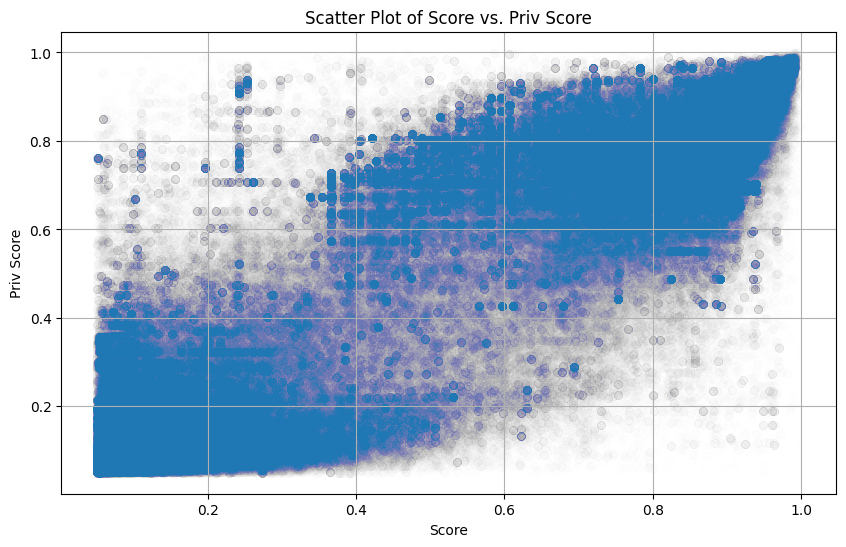

25/03/07 20:08:59 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1047029 ms exceeds timeout 120000 ms
25/03/07 20:08:59 WARN SparkContext: Killing executors is not supported by current scheduler.
25/03/07 20:24:22 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect the data into a Pandas DataFrame
pandas_df = joined_df.select("score", "score_priv").toPandas()

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(pandas_df["score"], pandas_df["score_priv"], alpha=0.005)
plt.title("Scatter Plot of Score vs. Priv Score")
plt.xlabel("Score")
plt.ylabel("Priv Score")
plt.grid(True)
plt.show()

# L2G direct associations

In [59]:
old_l2g_assoc=session.spark.read.parquet("gs://open-targets-pre-data-releases/24.09/output/etl/parquet/associationByDatasourceDirect")

In [60]:
old_l2g_assoc.show(1)

+----------------+------------+-------------+---------------+------------------+-------------+
|      datatypeId|datasourceId|    diseaseId|       targetId|             score|evidenceCount|
+----------------+------------+-------------+---------------+------------------+-------------+
|affected_pathway|      crispr|MONDO_0004986|ENSG00000068078|0.3525998626147402|            1|
+----------------+------------+-------------+---------------+------------------+-------------+
only showing top 1 row



In [61]:
old_l2g_assoc.groupBy("datasourceId").count().show()

+------------------+-------+
|      datasourceId|  count|
+------------------+-------+
|         europepmc|1469527|
|            crispr|    517|
|  uniprot_variants|   4365|
|  genomics_england|  10275|
|       gene_burden|   7469|
|            chembl|  81365|
|        slapenrich|  22953|
|  expression_atlas| 160627|
|           intogen|   2625|
|          reactome|   2488|
|          orphanet|   6259|
| cancer_biomarkers|    468|
|cancer_gene_census|  82754|
|           progeny|    378|
|           clingen|   2716|
|               eva|  36917|
|    gene2phenotype|   2697|
|uniprot_literature|   4497|
|       eva_somatic|   3522|
|ot_genetics_portal| 328419|
+------------------+-------+
only showing top 20 rows



In [62]:
old_l2g_assoc=old_l2g_assoc.filter(f.col("datasourceId")=="ot_genetics_portal").cache()
old_l2g_assoc.count()

328419

In [66]:
old_l2g_assoc.select("diseaseId").distinct().count()

3208

In [28]:
new_l2g_assoc=session.spark.read.parquet(path_to_release_folder+"output/association_by_datasource_direct")

In [29]:
new_l2g_assoc.show(1)

+----------+------------+-----------+---------------+--------------------+-------------+
|datatypeId|datasourceId|  diseaseId|       targetId|               score|evidenceCount|
+----------+------------+-----------+---------------+--------------------+-------------+
|literature|   europepmc|EFO_0000589|ENSG00000000938|0.012158615952232422|            1|
+----------+------------+-----------+---------------+--------------------+-------------+
only showing top 1 row



In [30]:
new_l2g_assoc.groupBy("datasourceId").count().show()

+------------------+-------+
|      datasourceId|  count|
+------------------+-------+
|gwas_credible_sets| 392784|
|         europepmc|2338196|
|            crispr|    517|
|  uniprot_variants|   5142|
|  genomics_england|  10500|
|       gene_burden|   7515|
|            chembl|  74197|
|        slapenrich|  22940|
|     crispr_screen|  10986|
|  expression_atlas| 160061|
|           intogen|   2596|
|          reactome|   2478|
|          orphanet|   6280|
| cancer_biomarkers|    468|
|cancer_gene_census|  82754|
|           progeny|    378|
|           clingen|   2964|
|               eva|  37576|
|    gene2phenotype|   3065|
|uniprot_literature|   6604|
+------------------+-------+
only showing top 20 rows



In [31]:
new_l2g_assoc=new_l2g_assoc.filter(f.col("datasourceId")=="gwas_credible_sets").cache()
new_l2g_assoc.count()

392784

In [63]:
new_l2g_assoc.filter(f.col("score")>=0.3).count()

192822

In [64]:
old_l2g_assoc.filter(f.col("score")>=0.3).count()

103587

In [32]:
new_l2g_assoc.select("diseaseId").distinct().count()

7462

In [ ]:

evidence=session.spark.read.parquet("gs://open-targets-data-releases/24.09/output/etl/parquet/evidence")

In [50]:
evidence.groupBy("datasourceId").count().show()

+------------------+--------+
|      datasourceId|   count|
+------------------+--------+
|         europepmc|11589523|
|               eva| 3040055|
|              impc| 1156920|
|ot_genetics_portal|  781213|
|            chembl|  652859|
|  expression_atlas|  230078|
|  genomics_england|   34456|
|       gene_burden|   36740|
|       eva_somatic|   17045|
|cancer_gene_census|   82754|
|        slapenrich|   72441|
|  uniprot_variants|   39568|
|          reactome|   10186|
|     crispr_screen|   21726|
|           intogen|    4359|
|          orphanet|    6271|
|uniprot_literature|    4602|
| cancer_biomarkers|    1300|
|    gene2phenotype|    3644|
|           clingen|    2764|
+------------------+--------+
only showing top 20 rows



In [51]:
evidence=evidence.filter(f.col("datasourceId")=="chembl").cache()
evidence.count()

652859

In [53]:
evidence.select("clinicalPhase","diseaseFromSourceMappedId","targetId").show()

+-------------+-------------------------+---------------+
|clinicalPhase|diseaseFromSourceMappedId|       targetId|
+-------------+-------------------------+---------------+
|          2.0|              EFO_0000203|ENSG00000004468|
|          2.0|              EFO_0000203|ENSG00000004468|
|          1.0|              EFO_1001249|ENSG00000004779|
|          2.0|              EFO_1001249|ENSG00000004779|
|          2.0|              EFO_0003768|ENSG00000011677|
|          2.0|              EFO_0003768|ENSG00000011677|
|          1.0|              EFO_0003768|ENSG00000011677|
|          0.5|              EFO_0003768|ENSG00000011677|
|          1.0|              EFO_0003768|ENSG00000011677|
|          2.0|              EFO_0003768|ENSG00000011677|
|          3.0|              EFO_0003768|ENSG00000011677|
|          4.0|              EFO_0002609|ENSG00000012779|
|          4.0|              EFO_0002609|ENSG00000012779|
|          4.0|              EFO_0002609|ENSG00000012779|
|          4.0

In [55]:
evidence1=evidence.select("clinicalPhase","diseaseFromSourceMappedId","targetId")

In [56]:
evidence1.groupBy("clinicalPhase").count().show()

+-------------+------+
|clinicalPhase| count|
+-------------+------+
|          1.0|126327|
|          4.0|185000|
|          0.5|  7181|
|          3.0|122280|
|          2.0|212071|
+-------------+------+



In [58]:
# Assuming evidence1 is your DataFrame
# Group by diseaseFromSourceMappedId and targetId, and calculate the maximum clinicalPhase
evidence1_agg = evidence1.groupBy("diseaseFromSourceMappedId", "targetId").agg(
    f.max(f.col("clinicalPhase")).alias("max_clinphaes")
)

evidence1_agg=evidence1_agg.filter(f.col("max_clinphaes")>=1).cache()
# Show the results
evidence1_agg.show(truncate=False)

+-------------------------+---------------+-------------+
|diseaseFromSourceMappedId|targetId       |max_clinphaes|
+-------------------------+---------------+-------------+
|MONDO_0021640            |ENSG00000037280|2.0          |
|EFO_0000544              |ENSG00000113327|4.0          |
|EFO_0003777              |ENSG00000117601|4.0          |
|MONDO_0003219            |ENSG00000157764|2.0          |
|EFO_1000238              |ENSG00000188229|3.0          |
|EFO_0007183              |ENSG00000096968|2.0          |
|MONDO_0004985            |ENSG00000145864|4.0          |
|MONDO_0100233            |ENSG00000184983|3.0          |
|EFO_0000313              |ENSG00000198786|2.0          |
|MONDO_0015564            |ENSG00000101162|1.0          |
|EFO_0003859              |ENSG00000104833|3.0          |
|MONDO_0008170            |ENSG00000128052|3.0          |
|HP_0100543               |ENSG00000185527|1.0          |
|EFO_0002617              |ENSG00000204389|1.0          |
|EFO_0000685  

In [59]:
evidence1_agg.count()

80079

In [61]:
l2g=l2g.withColumnRenamed("diseaseId","diseaseFromSourceMappedId")
l2g.show(1)

+-------------------------+---------------+------------------+
|diseaseFromSourceMappedId|       targetId|         score_l2g|
+-------------------------+---------------+------------------+
|              EFO_0000095|ENSG00000023171|0.7382962761085292|
+-------------------------+---------------+------------------+
only showing top 1 row



In [65]:
evidence1_agg1=evidence1_agg.join(l2g, ["diseaseFromSourceMappedId","targetId"], "left").fillna(0)

In [66]:
evidence1_agg1.show()

+-------------------------+---------------+-------------+---------+
|diseaseFromSourceMappedId|       targetId|max_clinphaes|score_l2g|
+-------------------------+---------------+-------------+---------+
|              EFO_0000313|ENSG00000198786|          2.0|      0.0|
|              EFO_0000544|ENSG00000113327|          4.0|      0.0|
|              EFO_0000685|ENSG00000012779|          4.0|      0.0|
|              EFO_0000729|ENSG00000113327|          4.0|      0.0|
|              EFO_0002617|ENSG00000204389|          1.0|      0.0|
|              EFO_0003085|ENSG00000101210|          2.0|      0.0|
|              EFO_0003768|ENSG00000153253|          3.0|      0.0|
|              EFO_0003777|ENSG00000117601|          4.0|      0.0|
|              EFO_0003859|ENSG00000104833|          3.0|      0.0|
|              EFO_0007183|ENSG00000096968|          2.0|      0.0|
|              EFO_0009441|ENSG00000170312|          1.0|      0.0|
|              EFO_1000238|ENSG00000188229|     

In [67]:
chembl_I_l2g=evidence1_agg1
chembl_I_l2g = chembl_I_l2g.withColumn(
    "chembl",
    f.when(f.col("max_clinphaes") >= 3, 1).otherwise(0)
).withColumn(
    "l2g",
    f.when(f.col("score_l2g") >= 0.3, 1).otherwise(0)
)

In [68]:
contingency_table = chembl_I_l2g.groupBy("l2g", "chembl").agg(f.count("*").alias("count"))

# Show the contingency table
contingency_table.show()

# Collect the counts into a dictionary for easier access
counts = { (row.l2g, row.chembl): row['count'] for row in contingency_table.collect() }

# Extract the counts for each combination
count_1_1 = counts.get((1, 1), 0)
count_1_0 = counts.get((1, 0), 0)
count_0_1 = counts.get((0, 1), 0)
count_0_0 = counts.get((0, 0), 0)

# Calculate the total counts
total_l2g_1 = count_1_1 + count_1_0
total_l2g_0 = count_0_1 + count_0_0
total_chembl_1 = count_1_1 + count_0_1
total_chembl_0 = count_1_0 + count_0_0
total = total_l2g_1 + total_l2g_0

# Calculate the enrichment
enrichment = (count_1_1 / total_l2g_1) / (total_chembl_1 / total)

# Print the results
print(f"Enrichment of binary l2g in binary chembl: {enrichment}")

+---+------+-----+
|l2g|chembl|count|
+---+------+-----+
|  1|     1|  523|
|  0|     0|43655|
|  0|     1|35564|
|  1|     0|  337|
+---+------+-----+



Enrichment of binary l2g in binary chembl: 1.3494944388270982


In [5]:
old_l2g_assoc.printSchema()

root
 |-- datatypeId: string (nullable = true)
 |-- datasourceId: string (nullable = true)
 |-- diseaseId: string (nullable = true)
 |-- targetId: string (nullable = true)
 |-- score: double (nullable = true)
 |-- evidenceCount: long (nullable = true)



In [6]:
old_l2g_assoc.groupBy("datasourceId").count().show()

+------------------+-------+
|      datasourceId|  count|
+------------------+-------+
|         europepmc|5330185|
|            crispr|   7496|
|  uniprot_variants|  44045|
|  genomics_england|  80184|
|       gene_burden|  21698|
|            chembl| 274919|
|        slapenrich| 269026|
|     crispr_screen|  45507|
|  expression_atlas| 160627|
|           intogen|  28083|
|          reactome|  16999|
|          orphanet|  62455|
|            sysbio|   2481|
| cancer_biomarkers|   5209|
|cancer_gene_census| 348633|
|           progeny|   2916|
|           clingen|  28019|
|               eva| 193130|
|    gene2phenotype|  30120|
|uniprot_literature|  45103|
+------------------+-------+
only showing top 20 rows



In [10]:
chembl=old_l2g_assoc.filter(f.col("datasourceId")=="chembl").cache()

In [11]:
chembl_I=chembl.filter(f.col("score")>=0.1).cache()

In [12]:
chembl_I.count()

228287

In [14]:
chembl_III=chembl.filter(f.col("score")>=0.7).cache()

In [15]:
chembl_III.count()

60849

In [16]:
chembl_I.show(1)

+----------+------------+-----------+---------------+-------------------+-------------+
|datatypeId|datasourceId|  diseaseId|       targetId|              score|evidenceCount|
+----------+------------+-----------+---------------+-------------------+-------------+
|known_drug|      chembl|EFO_0000584|ENSG00000027697|0.12158615952232422|            1|
+----------+------------+-----------+---------------+-------------------+-------------+
only showing top 1 row



In [18]:
l2g=old_l2g_assoc.filter(f.col("datasourceId")=="ot_genetics_portal")
l2g = l2g.dropDuplicates(["diseaseId", "targetId"]).cache()
l2g.count()

926370

In [19]:
chembl_I.count()

228287

In [24]:
l2g=l2g.select("diseaseId","targetId","score").withColumnRenamed("score","score_l2g")

In [30]:
chembl_I_l2g=chembl_I.join(l2g,["diseaseId","targetId"],"left").fillna(0).cache()

In [31]:
chembl_I_l2g.count()

228287

In [32]:
chembl_I_l2g.show()

+-----------+---------------+----------+------------+-------------------+-------------+---------+
|  diseaseId|       targetId|datatypeId|datasourceId|              score|evidenceCount|score_l2g|
+-----------+---------------+----------+------------+-------------------+-------------+---------+
|EFO_0000096|ENSG00000059758|known_drug|      chembl|0.13678442946261474|            2|      0.0|
|EFO_0000096|ENSG00000106588|known_drug|      chembl|0.15269987853546182|            7|      0.0|
|EFO_0000096|ENSG00000171552|known_drug|      chembl|0.18818572569838768|           24|      0.0|
|EFO_0000181|ENSG00000004779|known_drug|      chembl| 0.1713520500934755|            6|      0.0|
|EFO_0000181|ENSG00000177084|known_drug|      chembl|0.13678442946261474|            2|      0.0|
|EFO_0000181|ENSG00000188389|known_drug|      chembl| 0.9290372508636769|          179|      0.0|
|EFO_0000181|ENSG00000198763|known_drug|      chembl| 0.1713520500934755|            6|      0.0|
|EFO_0000198|ENSG000

In [44]:
chembl_I_l2g=chembl_I_l2g.select("score","score_l2g")
chembl_I_l2g = chembl_I_l2g.withColumn(
    "chembl",
    f.when(f.col("score") >= 0.8, 1).otherwise(0)
).withColumn(
    "l2g",
    f.when(f.col("score_l2g") >= 0.3, 1).otherwise(0)
)

In [45]:
chembl_I_l2g.show()

+-------------------+---------+------+---+
|              score|score_l2g|chembl|l2g|
+-------------------+---------+------+---+
|0.13678442946261474|      0.0|     0|  0|
|0.15269987853546182|      0.0|     0|  0|
|0.18818572569838768|      0.0|     0|  0|
| 0.1713520500934755|      0.0|     0|  0|
|0.13678442946261474|      0.0|     0|  0|
| 0.9290372508636769|      0.0|     1|  0|
| 0.1713520500934755|      0.0|     0|  0|
|0.12158615952232422|      0.0|     0|  0|
|0.12158615952232422|      0.0|     0|  0|
| 0.6245306857797384|      0.0|     0|  0|
| 0.8229365825518576|      0.0|     1|  0|
|0.14353921610274387|      0.0|     0|  0|
|0.44750461490855437|      0.0|     0|  0|
|0.47576638925088266|      0.0|     0|  0|
|  0.952389787341367|      0.0|     1|  0|
| 0.7599134970145264|      0.0|     0|  0|
|  0.607930797611621|      0.0|     0|  0|
| 0.1828886149103778|      0.0|     0|  0|
|0.12158615952232422|      0.0|     0|  0|
| 0.7810222052649298|      0.0|     0|  0|
+----------

In [46]:
chembl_I_l2g.groupBy("chembl").count().show()

+------+------+
|chembl| count|
+------+------+
|     1| 46824|
|     0|181463|
+------+------+



In [47]:
chembl_I_l2g.groupBy("l2g").count().show()

+---+------+
|l2g| count|
+---+------+
|  1|  5551|
|  0|222736|
+---+------+



In [48]:
contingency_table = chembl_I_l2g.groupBy("l2g", "chembl").agg(f.count("*").alias("count"))

# Show the contingency table
contingency_table.show()

# Collect the counts into a dictionary for easier access
counts = { (row.l2g, row.chembl): row['count'] for row in contingency_table.collect() }

# Extract the counts for each combination
count_1_1 = counts.get((1, 1), 0)
count_1_0 = counts.get((1, 0), 0)
count_0_1 = counts.get((0, 1), 0)
count_0_0 = counts.get((0, 0), 0)

# Calculate the total counts
total_l2g_1 = count_1_1 + count_1_0
total_l2g_0 = count_0_1 + count_0_0
total_chembl_1 = count_1_1 + count_0_1
total_chembl_0 = count_1_0 + count_0_0
total = total_l2g_1 + total_l2g_0

# Calculate the enrichment
enrichment = (count_1_1 / total_l2g_1) / (total_chembl_1 / total)

# Print the results
print(f"Enrichment of binary l2g in binary chembl: {enrichment}")

+---+------+------+
|l2g|chembl| count|
+---+------+------+
|  1|     0|  3241|
|  1|     1|  2310|
|  0|     0|178222|
|  0|     1| 44514|
+---+------+------+



Enrichment of binary l2g in binary chembl: 2.028866271572828


In [ ]:
chembl

In [11]:
old_l2g_assoc=session.spark.read.parquet("gs://open-targets-data-releases/24.09/output/etl/parquet/associationByDatasourceIndirect")
old_l2g_assoc=old_l2g_assoc.filter(f.col("datasourceId")=="ot_genetics_portal")
old_l2g_assoc = old_l2g_assoc.dropDuplicates(["diseaseId", "targetId"])
old_l2g_assoc.count()

926370

In [12]:
old_l2g_assoc.printSchema()

root
 |-- datatypeId: string (nullable = true)
 |-- datasourceId: string (nullable = true)
 |-- diseaseId: string (nullable = true)
 |-- targetId: string (nullable = true)
 |-- score: double (nullable = true)
 |-- evidenceCount: long (nullable = true)



In [13]:
old_l2g_assoc_f=old_l2g_assoc.filter(f.col("score")>=0.7)
old_l2g_assoc_f.count()

36141

In [14]:
old_l2g_assoc_f.select("diseaseId","targetId","score").write.parquet("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/EGL_old_l2g_indirect_0.7")

AnalysisException: path gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/EGL_old_l2g_indirect_0.7 already exists.

In [ ]:
old_l2g_assoc.select("score").describe().show()

+-------+-------------------+
|summary|              score|
+-------+-------------------+
|  count|             926370|
|   mean|0.24845702582043666|
| stddev| 0.2119742990646298|
|    min|0.03039660377410788|
|    max| 0.9348451933682167|
+-------+-------------------+



In [ ]:
old_l2g_assoc_f.select("diseaseId").distinct().count()

974

In [ ]:
old_l2g_assoc.filter(f.col("score")>=0.5).select("diseaseId").distinct().count()

1667

In [ ]:
new_l2g_evid=session.spark.read.parquet("gs://ot_orchestration/releases/24.10_freeze4/locus_to_gene_evidence/")

In [ ]:
new_l2g_evid.printSchema()

root
 |-- datatypeId: string (nullable = true)
 |-- datasourceId: string (nullable = true)
 |-- targetFromSourceId: string (nullable = true)
 |-- diseaseFromSourceMappedId: string (nullable = true)
 |-- resourceScore: double (nullable = true)
 |-- studyLocusId: string (nullable = true)



In [ ]:
new_l2g_evid.count()

1976318

In [ ]:
from pyspark.sql.types import DoubleType

def harmonic_sum(scores):
    scores = sorted(scores,reverse=True)
    ranks = range(1, len(scores) + 1)
    ranks2 = [r ** 2 for r in ranks]
    harmonic_sum_value = sum(score / rank2 for score, rank2 in zip(scores, ranks2))
    return float(harmonic_sum_value/1.644)

harmonic_sum_udf = f.udf(harmonic_sum, DoubleType())

new_l2g_evid=new_l2g_evid.withColumnRenamed("diseaseFromSourceMappedId","diseaseId").withColumnRenamed("targetFromSourceId","targetId")
new_l2g_assoc = new_l2g_evid.groupBy("diseaseId", "targetId").agg(
    harmonic_sum_udf(f.collect_list("resourceScore")).alias("harmonic_sum_score")
)

new_l2g_assoc.show(truncate=False)

+-----------+---------------+--------------------+
|diseaseId  |targetId       |harmonic_sum_score  |
+-----------+---------------+--------------------+
|EFO_0000094|ENSG00000008838|0.03259645365636378 |
|EFO_0000094|ENSG00000072682|0.444009273842943   |
|EFO_0000094|ENSG00000092067|0.0608363655615592  |
|EFO_0000094|ENSG00000104427|0.537851256982954   |
|EFO_0000094|ENSG00000132510|0.5414590609367256  |
|EFO_0000094|ENSG00000138386|0.07147482818842747 |
|EFO_0000094|ENSG00000164398|0.03680752884892539 |
|EFO_0000094|ENSG00000197057|0.14372857055187813 |
|EFO_0000094|ENSG00000229276|0.03428620550148676 |
|EFO_0000094|ENSG00000234756|0.09123216318985809 |
|EFO_0000094|ENSG00000240131|0.03767120785672864 |
|EFO_0000094|ENSG00000283207|0.036879051694817894|
|EFO_0000094|ENSG00000285730|0.0669635882562668  |
|EFO_0000095|ENSG00000006607|0.03885765271641728 |
|EFO_0000095|ENSG00000023171|0.8903505310982135  |
|EFO_0000095|ENSG00000025708|0.7286510220345761  |
|EFO_0000095|ENSG00000025770|0.

In [ ]:
new_l2g_assoc.count()

877176

In [ ]:
new_l2g_assoc.dropDuplicates(["diseaseId", "targetId"]).count()

877176

In [ ]:
new_l2g_assoc.select("diseaseId").distinct().count()

7537

In [ ]:
new_l2g_assoc.filter(f.col("harmonic_sum_score")>=0.5).select("diseaseId").distinct().count()

5976

In [ ]:
distinct_disease_ids = new_l2g_assoc.select("diseaseId").distinct()
new_disease_id_list = [row.diseaseId for row in distinct_disease_ids.collect()]

distinct_disease_ids =old_l2g_assoc.select("diseaseId").distinct()
old_disease_id_list = [row.diseaseId for row in distinct_disease_ids.collect()]

from collections import Counter
membership_counts = Counter([disease_id in new_disease_id_list for disease_id in old_disease_id_list])
print(membership_counts)


Counter({True: 2671, False: 537})


In [ ]:
distinct_disease_ids = new_l2g_assoc.select("diseaseId").distinct()
new_disease_id_list = [row.diseaseId for row in distinct_disease_ids.collect()]

distinct_disease_ids =old_l2g_assoc.filter(f.col("score")>=0.5).select("diseaseId").distinct()
old_disease_id_list = [row.diseaseId for row in distinct_disease_ids.collect()]

from collections import Counter
membership_counts = Counter([disease_id in new_disease_id_list for disease_id in old_disease_id_list])
print(membership_counts)

Counter({True: 1542, False: 125})


In [ ]:
old_l2g_assoc_f=old_l2g_assoc.filter(f.col("score")>=0.5)
old_l2g_assoc_f.count()

41006

In [ ]:
df=new_l2g_assoc.join(old_l2g_assoc_f,["diseaseId","targetId"],"inner")

In [ ]:
df.count()

31350

In [ ]:
df.show()

+-----------+---------------+-------------------+-------------------+------------------+------------------+-------------+
|  diseaseId|       targetId| harmonic_sum_score|         datatypeId|      datasourceId|             score|evidenceCount|
+-----------+---------------+-------------------+-------------------+------------------+------------------+-------------+
|EFO_0000095|ENSG00000023171| 0.8903505310982135|genetic_association|ot_genetics_portal|0.7382962761085292|           10|
|EFO_0000095|ENSG00000140968| 0.5357195128250322|genetic_association|ot_genetics_portal|0.7517636289532736|            5|
|EFO_0000195|ENSG00000084674| 0.7671803047844403|genetic_association|ot_genetics_portal|0.7414760007964251|            4|
|EFO_0000203|ENSG00000240505|0.27004691045251106|genetic_association|ot_genetics_portal|0.5062376445559743|            1|
|EFO_0000274|ENSG00000134954| 0.3691662564049608|genetic_association|ot_genetics_portal| 0.733251941703798|            6|
|EFO_0000274|ENSG0000018

In [ ]:
correlation = df.stat.corr("harmonic_sum_score", "score")
print(f"Correlation between harmonic_sum_score and score: {correlation}")

Correlation between harmonic_sum_score and score: 0.2618037539296765


In [ ]:
y=sl.df.filter(f.col("studyId")=="GCST90292538")

In [ ]:
y.count()

296

In [ ]:
sl=StudyLocus.from_parquet(session,"gs://gwas_catalog_sumstats_susie/credible_set_datasets/*",recursiveFileLookup=True)

In [ ]:
logs=session.spark.read.csv("gs://gwas_catalog_sumstats_susie/finemapping_logs/*",recursiveFileLookup=True,header=True,sep="\t")

In [ ]:
sl.df.write.parquet("gs://genetics-portal-dev-analysis/yt4/20241024_susie_GwasCatCredSets")

In [ ]:
logs.write.parquet("gs://genetics-portal-dev-analysis/yt4/20241024_susie_GwasCatLogs")

In [ ]:
logs.cache().groupBy("error").count().show(truncate=False)

+--------------------------------------------------------+-----+
|error                                                   |count|
+--------------------------------------------------------+-----+
|More than 15000 variants after joining GWAS and LD index|67   |
|Less than 100 variants after joining GWAS and LD index  |79   |
|Study type is not GWAS or non gwas catalog pqtl         |6100 |
|Quality control check failed for this study             |35315|
|Analysis Flags check failed for this study              |590  |
|No overlapping variants in the LD Index                 |155  |
|null                                                    |60698|
|Major ancestry is not nfe, csa or afr                   |1174 |
|No sumstats found for the studyId                       |1013 |
|No study index found for the studyId                    |16809|
+--------------------------------------------------------+-----+



In [ ]:
logs.count()

122000

In [ ]:
logs1=logs.filter(f.col("error").isNotNull())

In [ ]:
distinct_study_ids = logs1.select("studyId").distinct()

# Collect the results and convert to a list
study_id_list = [row.studyId for row in distinct_study_ids.collect()]


In [ ]:
len(study_id_list)

7722

In [ ]:
y=si.df.filter(f.col("studyId").isin(study_id_list)).select("studyId","qualityControls","analysisFlags","hasSumstats")

In [ ]:
y.count()

5913

In [ ]:
y.groupBy("qualityControls").count().show(truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|qualityControls                                                                                                                                                                                                                         |count|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|[The mean beta QC check value is not within the expected range, The GC lambda value is not within the expected range, The number of SNPs in the study is below the expected threshold]                                                  |3    |
|[]                                 

In [ ]:
y.groupBy("analysisFlags").count().show(truncate=False)

+-----------------------+-----+
|analysisFlags          |count|
+-----------------------+-----+
|[]                     |5421 |
|[Metabolite]           |285  |
|[Multivariate analysis]|13   |
|[ExWAS]                |163  |
|[Non-additive model]   |15   |
|[Case-case study]      |16   |
+-----------------------+-----+



In [ ]:
y.groupBy("hasSumstats").count().show()

+-----------+-----+
|hasSumstats|count|
+-----------+-----+
|       true| 5901|
|      false|   12|
+-----------+-----+



In [ ]:
y.groupBy(["qualityControls","hasSumstats","analysisFlags"]).count().show(truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+-----------------------+-----+
|qualityControls                                                                                                                                                                                                                         |hasSumstats|analysisFlags          |count|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+-----------------------+-----+
|[The PZ QC check values are not within the expected range]                                                                                                              

In [ ]:
y1 = y.filter(
    (f.size(f.col("qualityControls")) == 0) &
    (f.size(f.col("analysisFlags")) == 0) &
    (f.col("hasSumstats") == True)
)


In [ ]:
y1.count()

3596

In [ ]:
distinct_study_ids = y1.select("studyId").distinct()

# Collect the results and convert to a list
study_id_list = [row.studyId for row in distinct_study_ids.collect()]

In [ ]:
logs2=logs.filter(f.col("studyId").isin(study_id_list))

In [ ]:
logs2.groupBy("error").count().show(truncate=False)

+--------------------------------------------------------+-----+
|error                                                   |count|
+--------------------------------------------------------+-----+
|More than 15000 variants after joining GWAS and LD index|64   |
|Less than 100 variants after joining GWAS and LD index  |38   |
|Study type is not GWAS or non gwas catalog pqtl         |5343 |
|No overlapping variants in the LD Index                 |112  |
|null                                                    |7816 |
|Major ancestry is not nfe, csa or afr                   |425  |
+--------------------------------------------------------+-----+



In [ ]:
logs3=logs.filter(f.col("error").isNull())

In [ ]:
logs3.describe().show()

+-------+------------+--------------------+--------------------+------------------+------------------+------------------+----------+---------+------------------+------------------+------------------+-----+
|summary|     studyId|              region|N_gwas_before_dedupl|            N_gwas|              N_ld|         N_overlap|N_outliers|N_imputed|     N_final_to_fm|      elapsed_time|      number_of_CS|error|
+-------+------------+--------------------+--------------------+------------------+------------------+------------------+----------+---------+------------------+------------------+------------------+-----+
|  count|       60698|               60698|               60698|             60698|             60698|             60698|     60698|    60698|             60698|             60698|             60698|    0|
|   mean|        null|                null|  2943.7734851230684|2943.7734851230684|2943.7734851230684|2943.7734851230684|       0.0|      0.0|2943.7734851230684| 35.75933086979

# EGL list

In [5]:
#sgl=session.spark.read.parquet("gs://genetics-portal-dev-analysis/xg1/Effector_gene_list.parquet")
sgl=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/EGL_old_l2g_indirect_0.7")

In [6]:
sgl.show()

+-----------+---------------+------------------+
|  diseaseId|       targetId|             score|
+-----------+---------------+------------------+
|EFO_0000616|ENSG00000196616|0.7505301351240391|
|EFO_0010282|ENSG00000165406|0.7683801702714559|
|EFO_0010282|ENSG00000173175|0.8401876781478181|
|EFO_0010285|ENSG00000145996|0.8011118835995009|
|EFO_0000508|ENSG00000171791|0.7282174659778461|
|EFO_0000508|ENSG00000263715|0.7298928108701432|
|EFO_0004696|ENSG00000088451|0.7171647438927237|
|EFO_0004696|ENSG00000121858|0.7911208589105382|
|EFO_0004730|ENSG00000100344|0.8100202900247773|
|EFO_0004732|ENSG00000173068|0.8311625934957946|
|EFO_0004747|ENSG00000066926|0.7698423246509489|
|EFO_0004730|ENSG00000182732| 0.700076283188056|
|EFO_0004747|ENSG00000118985| 0.784901259198134|
|EFO_0004747|ENSG00000250361|0.7609888897431617|
|EFO_0006843|ENSG00000132359|0.8208041289284411|
|EFO_0006843|ENSG00000171840|0.7601763077284676|
|EFO_0006846|ENSG00000081237|0.7839806245453294|
|EFO_0004302|ENSG000

In [7]:
sgl.count()

36141

In [ ]:
fm=session.spark.read.parquet("gs://ot-team/irene/l2g/12112024/feature_matrix")

In [ ]:
si=StudyIndex.from_parquet(session,"gs://ot_orchestration/releases/24.10_freeze6/study_index")

In [ ]:
cs=StudyLocus.from_parquet(session,"gs://ot_orchestration/releases/24.10_freeze6/credible_set")

In [ ]:
cs=StudyLocus.from_parquet(session,"gs://ot_orchestration/releases/24.10_freeze6/credible_set")
cs=cs.df.select("studyLocusId","studyId")
cs=cs.dropDuplicates(["studyLocusId"])
result_df = fm.join(cs, on="studyLocusId", how="left")

In [30]:
si=si.df.select("studyId","traitFromSource","traitFromSourceMappedIds").dropDuplicates(["studyId"])
result_df = result_df.join(si, on="studyId", how="left")

In [ ]:
sgl = sgl.withColumnRenamed("geneId", "geneId_sgl")

In [12]:
joined_df = result_df.join(sgl, (f.array_contains(result_df["traitFromSourceMappedIds"], sgl["diseaseId"]))&(result_df["geneId"]==sgl["targetId"]),how="left")

#joined_df = result_df.join(sgl, (f.array_contains(result_df["traitFromSourceMappedIds"], sgl["efo_terms"]))&(result_df["geneId"]==sgl["geneId_sgl"]),how="left")

In [13]:
df=joined_df.filter(f.col("diseaseId").isNotNull())
#df=joined_df.filter(f.col("efo_terms").isNotNull())

In [ ]:
df.write.parquet("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/GSP_cs_old_l2g_07_freeze6")

In [50]:
df=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/GSP_cs_old_l2g_07_freeze6")
#df=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/GSP_cs_all_v2")

In [51]:
df = df.fillna(0)
#columns_to_update = ["distanceFootprintMean", "distanceTssMean"]

# Update the specified columns
#for col in columns_to_update:
#    df = df.withColumn(col, f.when(f.col(col) < 0, 0).otherwise(f.col(col)))


In [52]:
df = df.fillna(0)
x=["distanceSentinelFootprint","distanceSentinelTss","eQtlColocClppMaximum","pQtlColocClppMaximum","sQtlColocClppMaximum",
"eQtlColocH4Maximum","pQtlColocH4Maximum","sQtlColocH4Maximum","vepMaximum"]

df.select(x).describe().show()

+-------+-------------------------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------------+--------------------+-------------------+
|summary|distanceSentinelFootprint|distanceSentinelTss|eQtlColocClppMaximum|pQtlColocClppMaximum|sQtlColocClppMaximum| eQtlColocH4Maximum| pQtlColocH4Maximum|  sQtlColocH4Maximum|         vepMaximum|
+-------+-------------------------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------------+--------------------+-------------------+
|  count|                   169751|             169751|              169751|              169751|              169751|             169751|             169751|              169751|             169751|
|   mean|       0.7205882786896167| 0.6891033223364297|0.030696547014416133| 0.13970219586754581|0.016756751004845145|0.11494081440490427|0.09961788504285687|0.061927924589603965|0.09587272243528801|


In [53]:
df = df.withColumn("sum_column", sum(f.col(col) for col in x))

In [54]:
x=["distanceSentinelFootprint","distanceSentinelTss","eQtlColocClppMaximum","pQtlColocClppMaximum","sQtlColocClppMaximum",
"eQtlColocH4Maximum","pQtlColocH4Maximum","sQtlColocH4Maximum","vepMaximum","sum_column"]

In [55]:
df.select("distanceTssMean","studyLocusId").filter(f.col("distanceTssMean")<=-0.2).show(truncate=False)

+---------------+------------+
|distanceTssMean|studyLocusId|
+---------------+------------+
+---------------+------------+



In [56]:
df.filter(f.col("studyLocusId")=="c8d6cfa6b519f75e576262d957b1d80c").show(truncate=False)

+------------+--------------------------------+---------------+---------------------+---------------------+----------------------------------+-------------------------+--------------------------------------+-------------------+--------------------------------+---------------+----------------------------+--------------------+---------------------------------+------------------+-------------------------------+--------------+---------------+--------------------+---------------------------------+------------------+-------------------------------+---------------------+--------------------+---------------------------------+------------------+-------------------------------+----------+-----------------------+------------+--------------------+--------------------+------------------------+-----------+---------------+------------------+----------+
|studyId     |studyLocusId                    |geneId         |credibleSetConfidence|distanceFootprintMean|distanceFootprintMeanNeighbourhood|distance

In [57]:
fm=df.select(x)
fm.describe().show()

+-------+-------------------------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------------+--------------------+-------------------+------------------+
|summary|distanceSentinelFootprint|distanceSentinelTss|eQtlColocClppMaximum|pQtlColocClppMaximum|sQtlColocClppMaximum| eQtlColocH4Maximum| pQtlColocH4Maximum|  sQtlColocH4Maximum|         vepMaximum|        sum_column|
+-------+-------------------------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------------+--------------------+-------------------+------------------+
|  count|                   169751|             169751|              169751|              169751|              169751|             169751|             169751|              169751|             169751|            169751|
|   mean|       0.7205882786896167| 0.6891033223364297|0.030696547014416133| 0.13970219586754581|0.016756751004845145|0.1149

In [58]:
df.printSchema()

root
 |-- studyId: string (nullable = true)
 |-- studyLocusId: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- credibleSetConfidence: float (nullable = false)
 |-- distanceFootprintMean: float (nullable = false)
 |-- distanceFootprintMeanNeighbourhood: float (nullable = false)
 |-- distanceSentinelFootprint: float (nullable = false)
 |-- distanceSentinelFootprintNeighbourhood: float (nullable = false)
 |-- distanceSentinelTss: float (nullable = false)
 |-- distanceSentinelTssNeighbourhood: float (nullable = false)
 |-- distanceTssMean: float (nullable = false)
 |-- distanceTssMeanNeighbourhood: float (nullable = false)
 |-- eQtlColocClppMaximum: float (nullable = false)
 |-- eQtlColocClppMaximumNeighbourhood: float (nullable = false)
 |-- eQtlColocH4Maximum: float (nullable = false)
 |-- eQtlColocH4MaximumNeighbourhood: float (nullable = false)
 |-- geneCount500kb: double (nullable = false)
 |-- isProteinCoding: float (nullable = false)
 |-- pQtlColocClppMaximum: fl

In [59]:
from pyspark.sql import DataFrame, SparkSession, Window
window_spec = Window.partitionBy("geneId", "traitFromSourceMappedIds").orderBy(f.desc("distanceSentinelFootprint"),f.desc("distanceSentinelTss"),f.desc("sum_column"))

# Add row number to each row within the window specification
df_with_row_number = df.withColumn("row_number", f.row_number().over(window_spec))

# Filter rows to keep only the rows with row number 1
df_filtered = df_with_row_number.filter(f.col("row_number") == 1).drop("row_number")

# Show the results
df_filtered.count()

#df_filtered=df_filtered.filter(f.col("sum_column")>2)

17205

In [60]:
df_filtered.select(x).describe().show()

+-------+-------------------------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------------+------------------+-------------------+------------------+
|summary|distanceSentinelFootprint|distanceSentinelTss|eQtlColocClppMaximum|pQtlColocClppMaximum|sQtlColocClppMaximum| eQtlColocH4Maximum| pQtlColocH4Maximum|sQtlColocH4Maximum|         vepMaximum|        sum_column|
+-------+-------------------------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------------+------------------+-------------------+------------------+
|  count|                    17205|              17205|               17205|               17205|               17205|              17205|              17205|             17205|              17205|             17205|
|   mean|        0.929067591990679| 0.9046052371925547| 0.05496634191151359|0.047862526080584514|0.029102286664287415|0.186357263981

In [61]:
df_filtered.filter(f.col("distanceSentinelTss")>=0.1).select(x).describe().show()

+-------+-------------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+------------------+
|summary|distanceSentinelFootprint| distanceSentinelTss|eQtlColocClppMaximum|pQtlColocClppMaximum|sQtlColocClppMaximum| eQtlColocH4Maximum|  pQtlColocH4Maximum| sQtlColocH4Maximum|         vepMaximum|        sum_column|
+-------+-------------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+-------------------+-------------------+------------------+
|  count|                    15838|               15838|               15838|               15838|               15838|              15838|               15838|              15838|              15838|             15838|
|   mean|       0.9916573660868048|   0.982682984335011| 0.05965447636935542|0.030110391775229253| 0.03145323008482265|0

In [62]:
df1=df_filtered.filter(f.col("distanceSentinelTss")>=0.1)

In [63]:
df1.count()

15838

In [64]:
df1.drop("traitFromSourceMappedIds", "trait_efos") \
.repartition(1) \
.write.mode("overwrite") \
.option("delimiter", ";") \
.option("header", "true") \
.csv("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/GSP_cs_selected_freez6_v5")


df1.write.mode("overwrite").parquet("gs://genetics-portal-dev-analysis/yt4/20241024_EGL_playground/GSP_cs_selected_freez6_v5.parquet")

# OLD L2G predictions vs new

In [25]:
old=session.spark.read.parquet("gs://genetics-portal-dev-staging/l2g/220712/predictions/l2g.full.220712.parquet")

In [26]:
old.printSchema()

root
 |-- study_id: string (nullable = true)
 |-- chrom: string (nullable = true)
 |-- pos: long (nullable = true)
 |-- ref: string (nullable = true)
 |-- alt: string (nullable = true)
 |-- gene_id: string (nullable = true)
 |-- training_clf: string (nullable = true)
 |-- training_gs: string (nullable = true)
 |-- training_fold: string (nullable = true)
 |-- y_proba_dist_foot: double (nullable = true)
 |-- y_proba_dist_tss: double (nullable = true)
 |-- y_proba_full_model: double (nullable = true)
 |-- y_proba_logi_distance: double (nullable = true)
 |-- y_proba_logi_interaction: double (nullable = true)
 |-- y_proba_logi_molecularQTL: double (nullable = true)
 |-- y_proba_logi_pathogenicity: double (nullable = true)
 |-- y_proba_logo_distance: double (nullable = true)
 |-- y_proba_logo_interaction: double (nullable = true)
 |-- y_proba_logo_molecularQTL: double (nullable = true)
 |-- y_proba_logo_pathogenicity: double (nullable = true)



In [27]:
old.count()

4083797

In [28]:
old.select("study_id","pos").distinct().count()

319176

In [29]:
old.groupBy("training_gs").count().show()

+-----------+-------+
|training_gs|  count|
+-----------+-------+
|high_medium|4083797|
+-----------+-------+



In [ ]:
old.show(3)

+------------+-----+---------+---+---+---------------+------------+-----------+---------------+--------------------+--------------------+--------------------+---------------------+------------------------+-------------------------+--------------------------+---------------------+------------------------+-------------------------+--------------------------+
|    study_id|chrom|      pos|ref|alt|        gene_id|training_clf|training_gs|  training_fold|   y_proba_dist_foot|    y_proba_dist_tss|  y_proba_full_model|y_proba_logi_distance|y_proba_logi_interaction|y_proba_logi_molecularQTL|y_proba_logi_pathogenicity|y_proba_logo_distance|y_proba_logo_interaction|y_proba_logo_molecularQTL|y_proba_logo_pathogenicity|
+------------+-----+---------+---+---+---------------+------------+-----------+---------------+--------------------+--------------------+--------------------+---------------------+------------------------+-------------------------+--------------------------+---------------------+--

In [30]:
old=old.filter(f.col("y_proba_full_model")>=0.05).select("study_id","gene_id","y_proba_full_model").cache()

In [8]:
old.count()

781806

In [31]:
old=old.withColumnRenamed("study_id","studyId").withColumnRenamed("gene_id","geneId")

In [32]:
old.show(1)

+------------+---------------+-------------------+
|     studyId|         geneId| y_proba_full_model|
+------------+---------------+-------------------+
|GCST90018978|ENSG00000174059|0.05005302652716637|
+------------+---------------+-------------------+
only showing top 1 row



In [ ]:
#new=session.spark.read.parquet("gs://ot_orchestration/releases/24.11_freeze10/locus_to_gene_predictions")
#new_1=new

In [ ]:
#new=new.filter(f.col("locusToGeneFeatures").getItem("isProteinCoding") == 1).filter(f.col("score")>=0.05).select("studyLocusId","geneId","score").cache()

In [13]:
#new.count()

In [33]:
new=l2g

In [34]:
cs=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")
cs=cs.df.select("studyLocusId","studyId")
cs=cs.dropDuplicates(["studyLocusId"])
result_df = new.join(cs, on="studyLocusId", how="left").cache()
result_df.count()

992067

In [35]:
result_df=result_df.join(old,["studyId","geneId"],"inner").cache()
result_df.count()

289284

In [36]:
result_df.select("studyLocusId").distinct().count()

154979

In [37]:
result_df.show(1)

+----------+---------------+--------------------+-------------------+--------------------+-------------+------------------+
|   studyId|         geneId|        studyLocusId|              score|            features|shapBaseValue|y_proba_full_model|
+----------+---------------+--------------------+-------------------+--------------------+-------------+------------------+
|GCST000022|ENSG00000103494|0c62ef542fa26a34b...|0.12584525464259044|[{eQtlColocClppMa...|   0.07861334|0.2824871838092804|
+----------+---------------+--------------------+-------------------+--------------------+-------------+------------------+
only showing top 1 row



In [38]:
result_df.select("studyId").distinct().count()

6746

In [39]:
correlation = result_df.stat.corr("score", "y_proba_full_model")

# Print the result
print(f"Correlation between score and y_proba_full_model: {correlation}")

Correlation between score and y_proba_full_model: 0.5271776350573287


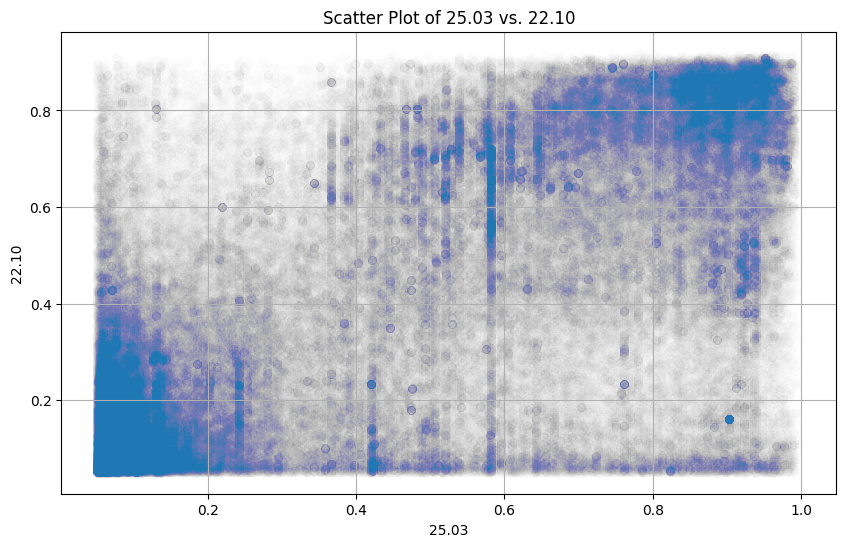

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect the data into a Pandas DataFrame
pandas_df = result_df.select("score", "y_proba_full_model").toPandas()

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(pandas_df["score"], pandas_df["y_proba_full_model"], alpha=0.005)
plt.title("Scatter Plot of 25.03 vs. 22.10")
plt.xlabel("25.03")
plt.ylabel("22.10")
plt.grid(True)
plt.show()

In [40]:
correlation = result_df.filter(f.col("score")>=0.5).stat.corr("score", "y_proba_full_model")

# Print the result
print(f"Correlation between score and y_proba_full_model with score>=0.5: {correlation}")

Correlation between score and y_proba_full_model with score>=0.5: 0.1431862146969575


In [21]:
thr = 0.5  # Example threshold value

# Add the new_score column
result_df_c = result_df.withColumn(
    "new_score",
    f.when(f.col("score") >= thr, 1).otherwise(0)
)

# Add the old_score column
result_df_c = result_df_c.withColumn(
    "old_score",
    f.when(f.col("y_proba_full_model") >= thr, 1).otherwise(0)
).cache()

result_df_c.show(1)

+----------+---------------+--------------------+-------------------+------------------+---------+---------+
|   studyId|         geneId|        studyLocusId|              score|y_proba_full_model|new_score|old_score|
+----------+---------------+--------------------+-------------------+------------------+---------+---------+
|GCST000022|ENSG00000103494|0c62ef542fa26a34b...|0.14528882397633278|0.2824871838092804|        0|        0|
+----------+---------------+--------------------+-------------------+------------------+---------+---------+
only showing top 1 row



In [22]:
result_df_c.groupBy("new_score").count().show()

+---------+------+
|new_score| count|
+---------+------+
|        1|147300|
|        0|162167|
+---------+------+



In [23]:
result_df_c.groupBy("old_score").count().show()

+---------+------+
|old_score| count|
+---------+------+
|        1|120700|
|        0|188767|
+---------+------+



In [24]:
# Assuming result_df_c is your DataFrame
# Group by new_score and old_score and count occurrences
counts_df = result_df_c.groupBy("new_score", "old_score").agg(f.count("*").alias("count"))

# Show the results
counts_df.show(truncate=False)

# Collect the results into a dictionary for easier access
counts = { (row.new_score, row.old_score): row['count'] for row in counts_df.collect() }

# Extract the counts for each combination
count_1_1 = counts.get((1, 1), 0)
count_1_0 = counts.get((1, 0), 0)
count_0_1 = counts.get((0, 1), 0)
count_0_0 = counts.get((0, 0), 0)

# Print the results
print(f"Count of (1, 1): {count_1_1}")
print(f"Count of (1, 0): {count_1_0}")
print(f"Count of (0, 1): {count_0_1}")
print(f"Count of (0, 0): {count_0_0}")

+---------+---------+------+
|new_score|old_score|count |
+---------+---------+------+
|1        |0        |52754 |
|1        |1        |94546 |
|0        |0        |136013|
|0        |1        |26154 |
+---------+---------+------+



Count of (1, 1): 94546
Count of (1, 0): 52754
Count of (0, 1): 26154
Count of (0, 0): 136013


In [148]:
result_df_c1=result_df_c.join(new_1.drop("score"),["studyLocusId","geneId"],"inner")
result_df_c1.filter((f.col("y_proba_full_model")>=0.8) & (f.col("score")<=0.2)).show(5,truncate=False)

+--------------------------------+---------------+------------+-------------------+------------------+---------+---------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [150]:
x=["5c9e3f0dd42281b85fd0cbc8acdbfef0","92c4440fcbf6ee3057f9da0aaa67b23e",
   "aec0838431d2c527d7500a4134a66452","f4d3fe924ccb4c8860d9465df7f4d979"]
result_df_c1.filter(f.col("studyLocusId").isin(x)).drop_duplicates(["studyLocusId","geneId"]).show(100,truncate=False)

+--------------------------------+---------------+------------+-------------------+--------------------+---------+---------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [120]:
thr = 0.8  # Example threshold value

# Add the new_score column
result_df_c = result_df.withColumn(
    "new_score",
    f.when(f.col("score") >= thr, 1).otherwise(0)
)

# Add the old_score column
result_df_c = result_df_c.withColumn(
    "old_score",
    f.when(f.col("y_proba_full_model") >= thr, 1).otherwise(0)
).cache()

result_df_c.show(1)

# Assuming result_df_c is your DataFrame
# Group by new_score and old_score and count occurrences
counts_df = result_df_c.groupBy("new_score", "old_score").agg(f.count("*").alias("count"))

# Show the results
counts_df.show(truncate=False)

# Collect the results into a dictionary for easier access
counts = { (row.new_score, row.old_score): row['count'] for row in counts_df.collect() }

# Extract the counts for each combination
count_1_1 = counts.get((1, 1), 0)
count_1_0 = counts.get((1, 0), 0)
count_0_1 = counts.get((0, 1), 0)
count_0_0 = counts.get((0, 0), 0)

# Print the results
print(f"Count of (1, 1): {count_1_1}")
print(f"Count of (1, 0): {count_1_0}")
print(f"Count of (0, 1): {count_0_1}")
print(f"Count of (0, 0): {count_0_0}")

+----------+---------------+--------------------+-------------------+------------------+---------+---------+
|   studyId|         geneId|        studyLocusId|              score|y_proba_full_model|new_score|old_score|
+----------+---------------+--------------------+-------------------+------------------+---------+---------+
|GCST000043|ENSG00000065361|fff3ba657ccbdd51f...|0.16959128139829466|0.4851868450641632|        0|        0|
+----------+---------------+--------------------+-------------------+------------------+---------+---------+
only showing top 1 row



+---------+---------+------+
|new_score|old_score|count |
+---------+---------+------+
|1        |0        |55380 |
|1        |1        |19337 |
|0        |0        |209283|
|0        |1        |10478 |
+---------+---------+------+

Count of (1, 1): 19337
Count of (1, 0): 55380
Count of (0, 1): 10478
Count of (0, 0): 209283


In [170]:
new1=session.spark.read.parquet("gs://ot_orchestration/benchmarks/l2g/fm0/gs_v1/locus_to_gene_predictions")
new2=session.spark.read.parquet("gs://ot_orchestration/benchmarks/l2g/fm1/v1/locus_to_gene_predictions")

In [171]:
new1.show(1)

+--------------------+---------------+-------------------+--------------------+
|        studyLocusId|         geneId|              score| locusToGeneFeatures|
+--------------------+---------------+-------------------+--------------------+
|00020556c608357ed...|ENSG00000149591|0.05566414803868742|{eQtlColocClppMax...|
+--------------------+---------------+-------------------+--------------------+
only showing top 1 row



In [172]:
new2.show(1)

+--------------------+---------------+------------------+--------------------+
|        studyLocusId|         geneId|             score| locusToGeneFeatures|
+--------------------+---------------+------------------+--------------------+
|00050f2c3b0b5f3ce...|ENSG00000150244|0.2111529418080288|{credibleSetConfi...|
+--------------------+---------------+------------------+--------------------+
only showing top 1 row



In [173]:
new1=new1.filter(f.col("locusToGeneFeatures").getItem("isProteinCoding") == 1).filter(f.col("score")>=0.05).select("studyLocusId","geneId","score").cache()
new1.count()

1144241

In [174]:
new2=new2.filter(f.col("locusToGeneFeatures").getItem("isProteinCoding") == 1).filter(f.col("score")>=0.05).select("studyLocusId","geneId","score").cache()
new2.count()

1079156

In [175]:
new1=new1.select("studyLocusId","geneId","score").withColumnRenamed("score","score1").cache()

In [176]:
new3=new2.join(new1,["studyLocusId","geneId"],"inner").cache()

In [177]:
new3.count()

821535

In [178]:
new3.show(1)

+--------------------+---------------+-------------------+------------------+
|        studyLocusId|         geneId|              score|            score1|
+--------------------+---------------+-------------------+------------------+
|00117f0551bb5139e...|ENSG00000077616|0.43436767668624865|0.3646920396801779|
+--------------------+---------------+-------------------+------------------+
only showing top 1 row



In [179]:
correlation = new3.stat.corr("score", "score1")

# Print the result
print(f"Correlation between score and y_proba_full_model with score>=0.5: {correlation}")

Correlation between score and y_proba_full_model with score>=0.5: 0.7983773444377988


In [182]:
thr = 0.8  # Example threshold value

# Add the new_score column
result_df_c = new3.withColumn(
    "new_score",
    f.when(f.col("score") >= thr, 1).otherwise(0)
)

# Add the old_score column
result_df_c = result_df_c.withColumn(
    "old_score",
    f.when(f.col("score1") >= thr, 1).otherwise(0)
).cache()

result_df_c.show(1)

# Assuming result_df_c is your DataFrame
# Group by new_score and old_score and count occurrences
counts_df = result_df_c.groupBy("new_score", "old_score").agg(f.count("*").alias("count"))

# Show the results
counts_df.show(truncate=False)

# Collect the results into a dictionary for easier access
counts = { (row.new_score, row.old_score): row['count'] for row in counts_df.collect() }

# Extract the counts for each combination
count_1_1 = counts.get((1, 1), 0)
count_1_0 = counts.get((1, 0), 0)
count_0_1 = counts.get((0, 1), 0)
count_0_0 = counts.get((0, 0), 0)

# Print the results
print(f"Count of (1, 1): {count_1_1}")
print(f"Count of (1, 0): {count_1_0}")
print(f"Count of (0, 1): {count_0_1}")
print(f"Count of (0, 0): {count_0_0}")

+--------------------+---------------+-------------------+------------------+---------+---------+
|        studyLocusId|         geneId|              score|            score1|new_score|old_score|
+--------------------+---------------+-------------------+------------------+---------+---------+
|00117f0551bb5139e...|ENSG00000077616|0.43436767668624865|0.3646920396801779|        0|        0|
+--------------------+---------------+-------------------+------------------+---------+---------+
only showing top 1 row



+---------+---------+------+
|new_score|old_score|count |
+---------+---------+------+
|1        |0        |36449 |
|1        |1        |73416 |
|0        |0        |673620|
|0        |1        |38050 |
+---------+---------+------+

Count of (1, 1): 73416
Count of (1, 0): 36449
Count of (0, 1): 38050
Count of (0, 0): 673620


In [184]:
new3.filter(f.col("studyLocusId")=="92c4440fcbf6ee3057f9da0aaa67b23e").show(truncate=False)

+--------------------------------+---------------+-----------------+-------------------+
|studyLocusId                    |geneId         |score            |score1             |
+--------------------------------+---------------+-----------------+-------------------+
|92c4440fcbf6ee3057f9da0aaa67b23e|ENSG00000017427|0.640153790286134|0.25622836478576116|
+--------------------------------+---------------+-----------------+-------------------+



In [186]:
new3.filter(f.col("studyLocusId")=="f4d3fe924ccb4c8860d9465df7f4d979").show(truncate=False)

+--------------------------------+---------------+-------------------+-------------------+
|studyLocusId                    |geneId         |score              |score1             |
+--------------------------------+---------------+-------------------+-------------------+
|f4d3fe924ccb4c8860d9465df7f4d979|ENSG00000164066|0.35570995519908494|0.4551593720525071 |
|f4d3fe924ccb4c8860d9465df7f4d979|ENSG00000151475|0.09212510244933772|0.07882615286070795|
|f4d3fe924ccb4c8860d9465df7f4d979|ENSG00000142731|0.27508186255074396|0.06029226181122695|
+--------------------------------+---------------+-------------------+-------------------+



In [187]:

new3.filter(f.col("studyLocusId")=="0b1384451666f2d7e94f6697d6502b3b").show(truncate=False)

+--------------------------------+---------------+-------------------+-------------------+
|studyLocusId                    |geneId         |score              |score1             |
+--------------------------------+---------------+-------------------+-------------------+
|0b1384451666f2d7e94f6697d6502b3b|ENSG00000073711|0.1292491038191361 |0.2274251651892725 |
|0b1384451666f2d7e94f6697d6502b3b|ENSG00000174579|0.22837157178577122|0.05056854241008014|
+--------------------------------+---------------+-------------------+-------------------+

